In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Confirmed paths from your directory scan
SPLITS = {
    'train': Path('/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train'),
    'val':   Path('/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val'),
    'test':  Path('/kaggle/input/visdrone-dataset/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev'),
}

CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']

CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

# VisDrone annotation format:
# bbox_left, bbox_top, bbox_width, bbox_height, score, category, truncation, occlusion
# category: 0=ignored, 1-10=classes, 11=others
# occlusion: 0=none, 1=partial(1-50%), 2=heavy(>50%)
# truncation: 0=none, 1=partial(1-50%)

print("Paths verified:")
for name, path in SPLITS.items():
    imgs = len(list((path/'images').glob('*.jpg')))
    anns = len(list((path/'annotations').glob('*.txt'))) if (path/'annotations').exists() else 0
    print(f"  {name:6s}: {imgs} images, {anns} annotations")

Paths verified:
  train : 0 images, 0 annotations
  val   : 0 images, 0 annotations
  test  : 0 images, 0 annotations


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

SPLITS = {
    'train': Path('/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train'),
    'val':   Path('/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val'),
    'test':  Path('/kaggle/input/datasets/kushagrapandya/visdrone-dataset/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev'),
}

CLASS_NAMES = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

print("Paths verified:")
for name, path in SPLITS.items():
    imgs = len(list((path/'images').glob('*.jpg')))
    anns = len(list((path/'annotations').glob('*.txt'))) if (path/'annotations').exists() else 0
    print(f"  {name:6s}: {imgs} images, {anns} annotations")

Paths verified:
  train : 6471 images, 6471 annotations
  val   : 548 images, 548 annotations
  test  : 1610 images, 1610 annotations


In [2]:
from PIL import Image
from pathlib import Path

img_dir = SPLITS['train'] / 'images'
sample_imgs = sorted(img_dir.glob('*.jpg'))[:20]

sizes = set()
for img_path in sample_imgs:
    w, h = Image.open(img_path).size
    sizes.add((w, h))

print("Unique sizes found:")
for s in sorted(sizes):
    print(f"  {s[0]} × {s[1]}")

Unique sizes found:
  960 × 540
  1360 × 765


Parsing annotations...
  train: 343,205 objects
  val: 38,759 objects
  test: 75,102 objects


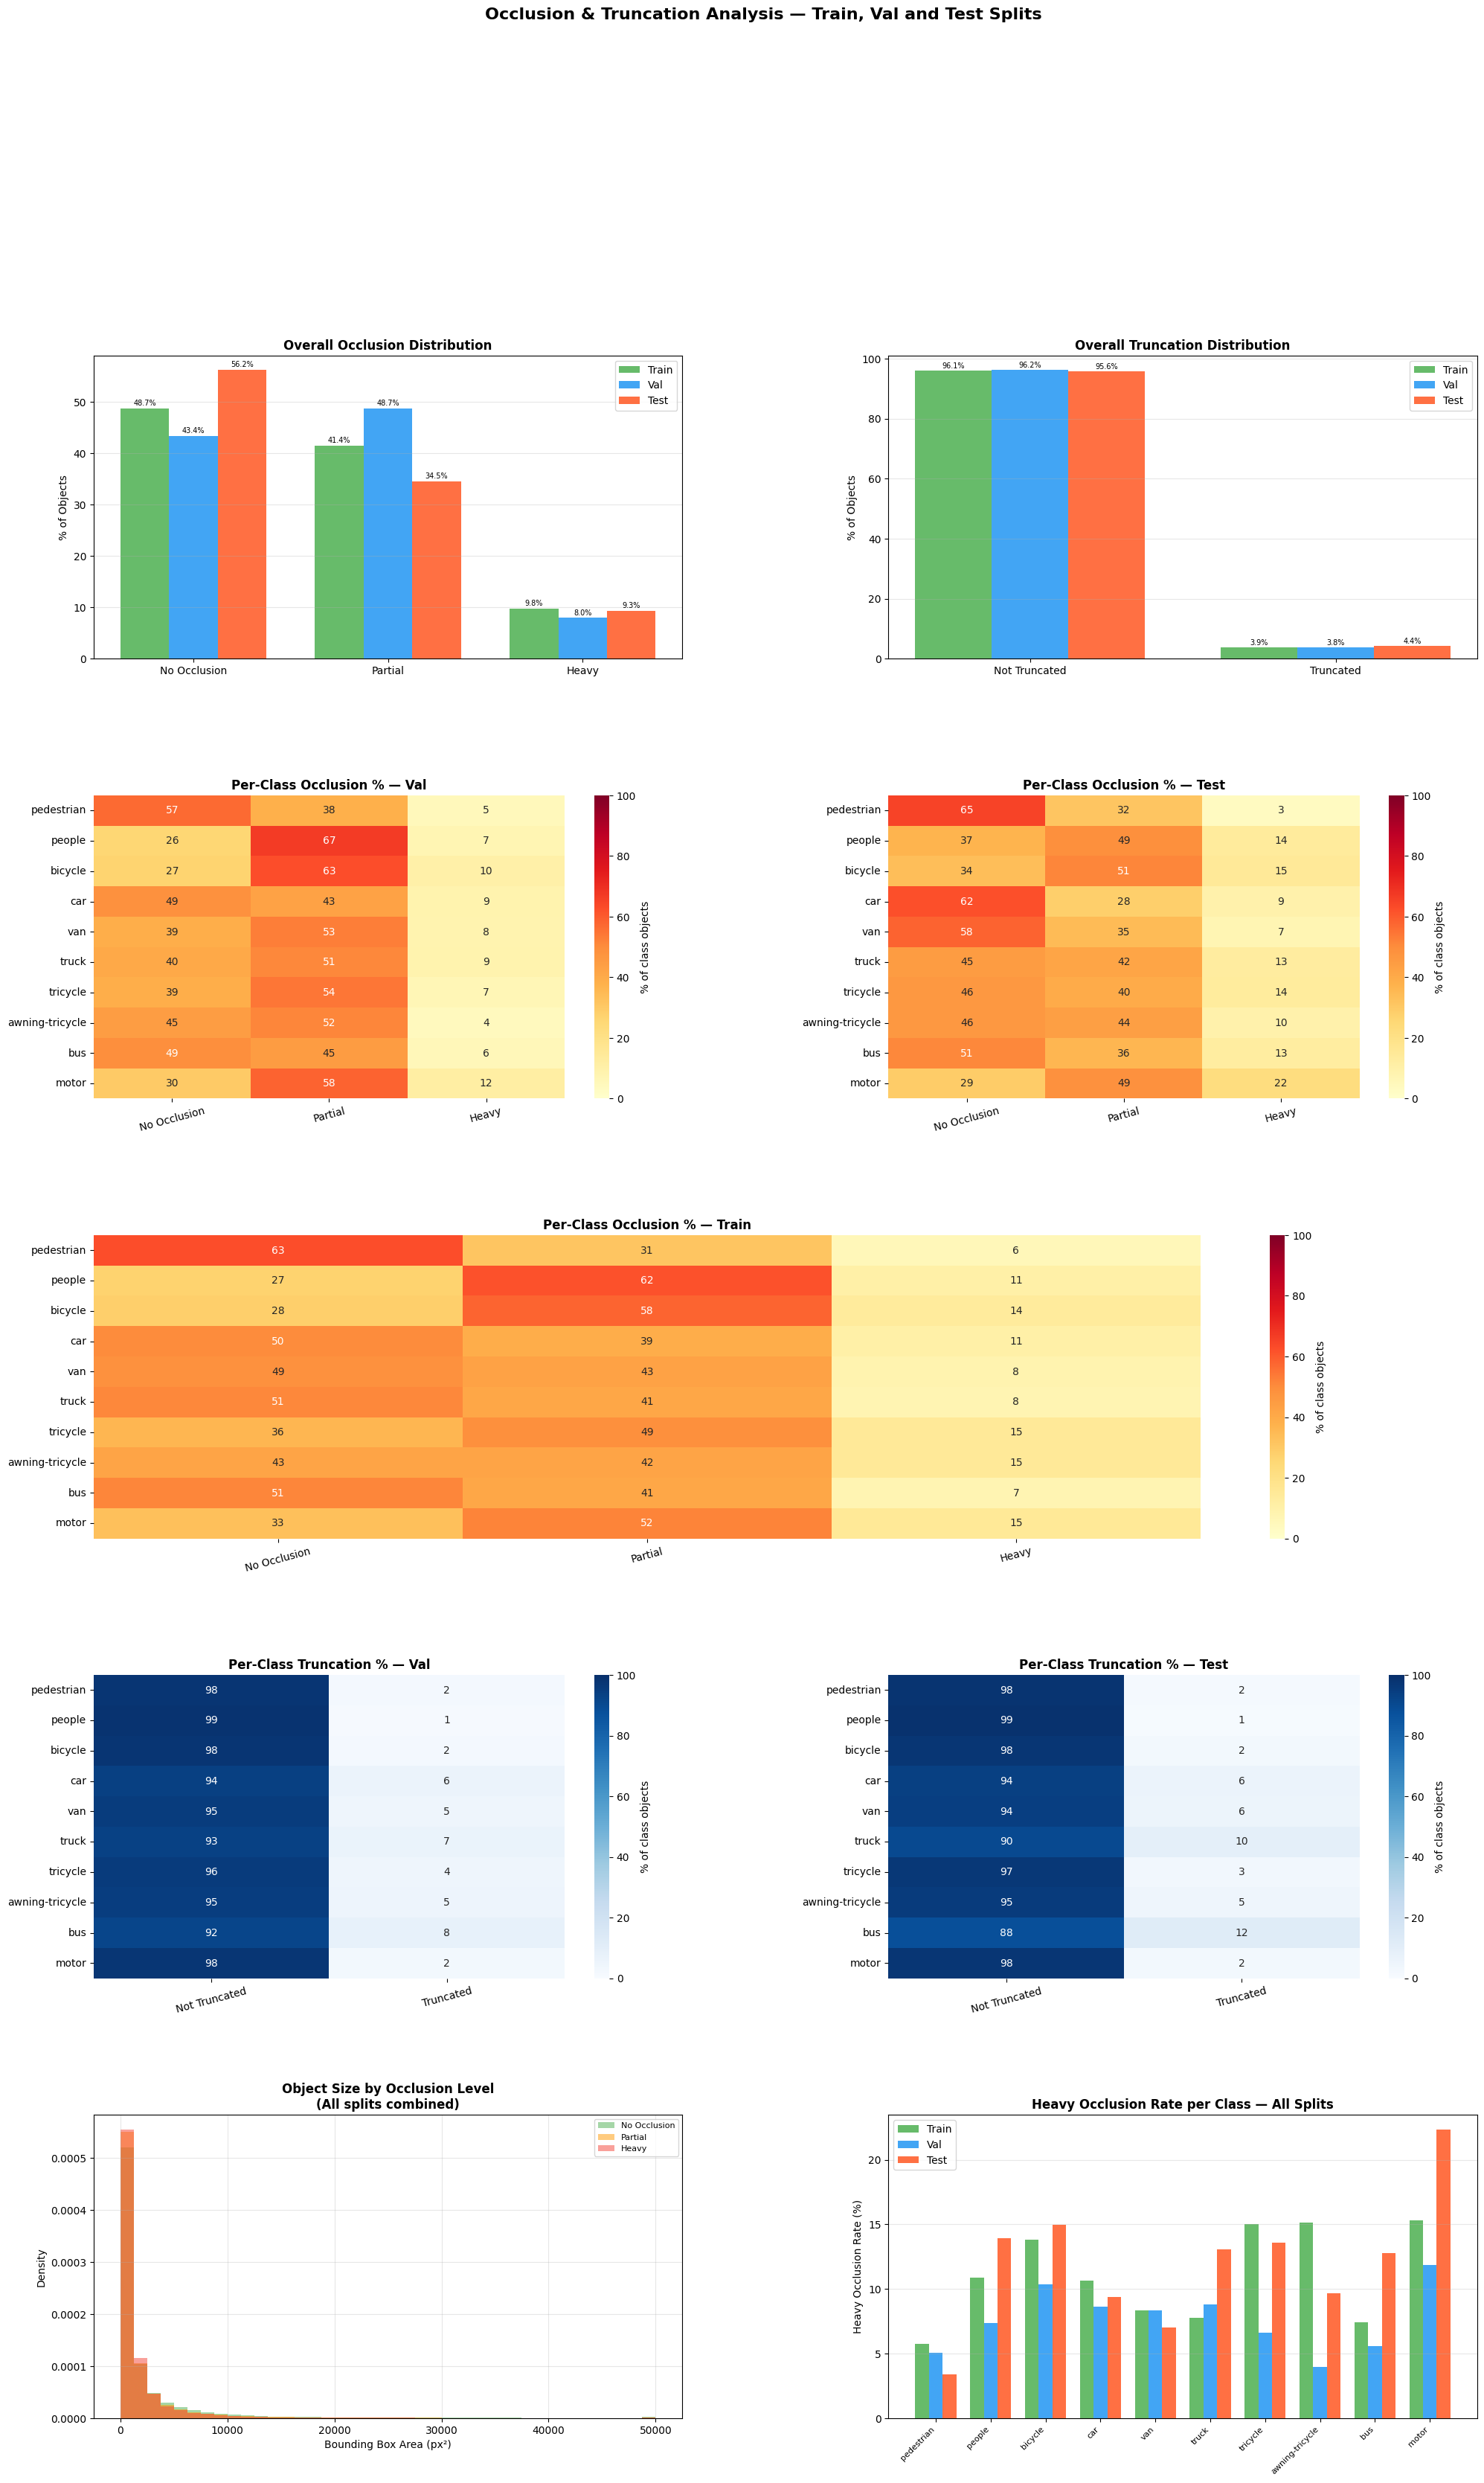

✅ Saved to /kaggle/working/occlusion_truncation_analysis.png

Summary — Heavy Occlusion & Truncation Rates
Split       Heavy Occ    Truncated   Total Objects
--------------------------------------------------
train            9.8%         3.9%         343,205
val              8.0%         3.8%          38,759
test             9.3%         4.4%          75,102


In [4]:
# Occlusion & Truncation Analysis — Train, Val and Test splits

OCCLUSION_LABELS  = {0: 'No Occlusion', 1: 'Partial', 2: 'Heavy'}
TRUNCATION_LABELS = {0: 'Not Truncated', 1: 'Truncated'}

def parse_annotations(split_path):
    records = []
    ann_dir = split_path / 'annotations'
    for ann_file in sorted(ann_dir.glob('*.txt')):
        for row in ann_file.read_text().strip().splitlines():
            parts = row.strip().split(',')
            if len(parts) < 8:
                continue
            bx, by, bw, bh = map(float, parts[:4])
            score      = int(parts[4])
            category   = int(parts[5])
            truncation = int(parts[6])
            occlusion  = int(parts[7])
            if score == 0 or category in (0, 11):
                continue
            records.append({
                'class':      CLASS_NAMES[category - 1],
                'class_idx':  category - 1,
                'truncation': truncation,
                'occlusion':  occlusion,
                'area':       bw * bh,
            })
    return pd.DataFrame(records)

print("Parsing annotations...")
dfs = {}
for split in ['train', 'val', 'test']:
    dfs[split] = parse_annotations(SPLITS[split])
    print(f"  {split}: {len(dfs[split]):,} objects")

SPLIT_COLORS = {'train': '#4CAF50', 'val': '#2196F3', 'test': '#FF5722'}

fig = plt.figure(figsize=(24, 36))
fig.suptitle('Occlusion & Truncation Analysis — Train, Val and Test Splits',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Overall occlusion distribution ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x     = np.arange(3)
width = 0.25
for i, split in enumerate(['train', 'val', 'test']):
    counts = [( dfs[split]['occlusion'] == k).sum() for k in range(3)]
    totals = sum(counts)
    pcts   = [c / totals * 100 for c in counts]
    bars   = ax1.bar(x + i*width, pcts, width,
                      label=split.capitalize(),
                      color=SPLIT_COLORS[split], alpha=0.85)
    for bar, pct in zip(bars, pcts):
        ax1.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)
ax1.set_xticks(x + width)
ax1.set_xticklabels([OCCLUSION_LABELS[k] for k in range(3)])
ax1.set_ylabel('% of Objects')
ax1.set_title('Overall Occlusion Distribution', fontweight='bold')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# ── 2. Overall truncation distribution ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
x     = np.arange(2)
width = 0.25
for i, split in enumerate(['train', 'val', 'test']):
    counts = [(dfs[split]['truncation'] == k).sum() for k in range(2)]
    totals = sum(counts)
    pcts   = [c / totals * 100 for c in counts]
    bars   = ax2.bar(x + i*width, pcts, width,
                      label=split.capitalize(),
                      color=SPLIT_COLORS[split], alpha=0.85)
    for bar, pct in zip(bars, pcts):
        ax2.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)
ax2.set_xticks(x + width)
ax2.set_xticklabels([TRUNCATION_LABELS[k] for k in range(2)])
ax2.set_ylabel('% of Objects')
ax2.set_title('Overall Truncation Distribution', fontweight='bold')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

# ── 3-5. Per-class occlusion heatmaps ──────────────────────────────────────
for col, split in enumerate(['val', 'test']):
    ax = fig.add_subplot(gs[1, col])
    matrix = np.zeros((10, 3))
    for c in range(10):
        sub = dfs[split][dfs[split]['class_idx'] == c]['occlusion']
        if len(sub):
            for o in range(3):
                matrix[c, o] = (sub == o).sum() / len(sub) * 100
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.0f',
                xticklabels=[OCCLUSION_LABELS[k] for k in range(3)],
                yticklabels=CLASS_NAMES,
                cmap='YlOrRd', vmin=0, vmax=100,
                cbar_kws={'label': '% of class objects'})
    ax.set_title(f'Per-Class Occlusion % — {split.capitalize()}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

# Train occlusion heatmap spans full width
ax_tr_occ = fig.add_subplot(gs[2, :])
matrix_tr = np.zeros((10, 3))
for c in range(10):
    sub = dfs['train'][dfs['train']['class_idx'] == c]['occlusion']
    if len(sub):
        for o in range(3):
            matrix_tr[c, o] = (sub == o).sum() / len(sub) * 100
sns.heatmap(matrix_tr, ax=ax_tr_occ, annot=True, fmt='.0f',
            xticklabels=[OCCLUSION_LABELS[k] for k in range(3)],
            yticklabels=CLASS_NAMES,
            cmap='YlOrRd', vmin=0, vmax=100,
            cbar_kws={'label': '% of class objects'})
ax_tr_occ.set_title('Per-Class Occlusion % — Train', fontweight='bold')
ax_tr_occ.tick_params(axis='x', rotation=15)

# ── 6-7. Per-class truncation heatmaps — Val and Test ──────────────────────
for col, split in enumerate(['val', 'test']):
    ax = fig.add_subplot(gs[3, col])
    matrix = np.zeros((10, 2))
    for c in range(10):
        sub = dfs[split][dfs[split]['class_idx'] == c]['truncation']
        if len(sub):
            for t in range(2):
                matrix[c, t] = (sub == t).sum() / len(sub) * 100
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.0f',
                xticklabels=[TRUNCATION_LABELS[k] for k in range(2)],
                yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=100,
                cbar_kws={'label': '% of class objects'})
    ax.set_title(f'Per-Class Truncation % — {split.capitalize()}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

# ── 8. Object size distribution by occlusion — all splits combined ─────────
ax8 = fig.add_subplot(gs[4, 0])
combined = pd.concat([dfs['train'], dfs['val'], dfs['test']])
for occ_level, color in zip(range(3), ['#4CAF50', '#FF9800', '#F44336']):
    sub = combined[combined['occlusion'] == occ_level]['area'].clip(upper=50000)
    ax8.hist(sub, bins=40, alpha=0.5, color=color,
              label=OCCLUSION_LABELS[occ_level], density=True)
ax8.set_xlabel('Bounding Box Area (px²)')
ax8.set_ylabel('Density')
ax8.set_title('Object Size by Occlusion Level\n(All splits combined)',
               fontweight='bold')
ax8.legend(fontsize=8); ax8.grid(alpha=0.3)

# ── 9. Heavy occlusion rate per class — all 3 splits ───────────────────────
ax9 = fig.add_subplot(gs[4, 1])
x     = np.arange(10)
width = 0.25
for i, split in enumerate(['train', 'val', 'test']):
    rates = []
    for c in range(10):
        sub  = dfs[split][dfs[split]['class_idx'] == c]
        rate = (sub['occlusion'] == 2).sum() / len(sub) * 100 if len(sub) else 0
        rates.append(rate)
    ax9.bar(x + i*width, rates, width,
             label=split.capitalize(),
             color=SPLIT_COLORS[split], alpha=0.85)
ax9.set_xticks(x + width)
ax9.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax9.set_ylabel('Heavy Occlusion Rate (%)')
ax9.set_title('Heavy Occlusion Rate per Class — All Splits', fontweight='bold')
ax9.legend(); ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/occlusion_truncation_analysis.png',
             dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to /kaggle/working/occlusion_truncation_analysis.png")

print("\nSummary — Heavy Occlusion & Truncation Rates")
print(f"{'Split':<8} {'Heavy Occ':>12} {'Truncated':>12} {'Total Objects':>15}")
print("-"*50)
for split in ['train', 'val', 'test']:
    df = dfs[split]
    print(f"{split:<8} "
          f"{(df['occlusion']==2).mean()*100:>11.1f}% "
          f"{(df['truncation']==1).mean()*100:>11.1f}% "
          f"{len(df):>15,}")

In [8]:
def parse_annotations(split_path, split_name):
    records = []
    ann_dir = split_path / 'annotations'
    img_dir = split_path / 'images'

    if not ann_dir.exists():
        print(f"No annotations for {split_name}")
        return pd.DataFrame()

    for ann_file in sorted(ann_dir.glob('*.txt')):
        img_file = img_dir / (ann_file.stem + '.jpg')
        try:
            W, H = Image.open(img_file).size
        except:
            continue

        with open(ann_file) as f:
            lines = f.read().strip().splitlines()

        if not lines or lines == ['']:
            continue

        for line in lines:
            parts = line.strip().split(',')
            if len(parts) < 8:
                continue
            bx, by, bw, bh = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
            score = int(parts[4])
            cat   = int(parts[5])
            trunc = int(parts[6])
            occ   = int(parts[7])

            if score == 0 or cat == 0 or cat == 11 or bw <= 0 or bh <= 0:
                continue

            area = bw * bh
            cx   = bx + bw/2
            cy   = by + bh/2

            records.append({
                'split':      split_name,
                'image':      ann_file.stem,
                'img_w':      W, 'img_h': H,
                'x': bx, 'y': by, 'w': bw, 'h': bh,
                'cx_norm':    cx / W,
                'cy_norm':    cy / H,
                'w_norm':     bw / W,
                'h_norm':     bh / H,
                'area':       area,
                'area_norm':  area / (W * H),
                'aspect':     bw / bh if bh > 0 else 0,
                'class_id':   cat - 1,
                'class_name': CLASS_NAMES[cat - 1],
                'truncation': trunc,
                'occlusion':  occ,
                'img_pixels': W * H,
            })

    return pd.DataFrame(records)

print("Parsing annotations...")
dfs = {}
for name, path in SPLITS.items():
    dfs[name] = parse_annotations(path, name)
    print(f"  {name}: {len(dfs[name]):,} objects")

df_all   = pd.concat(dfs.values(), ignore_index=True)
df_train = dfs['train']
print(f"\nTotal objects: {len(df_all):,}")

Parsing annotations...
  train: 343,204 objects
  val: 38,759 objects
  test: 75,102 objects

Total objects: 457,065


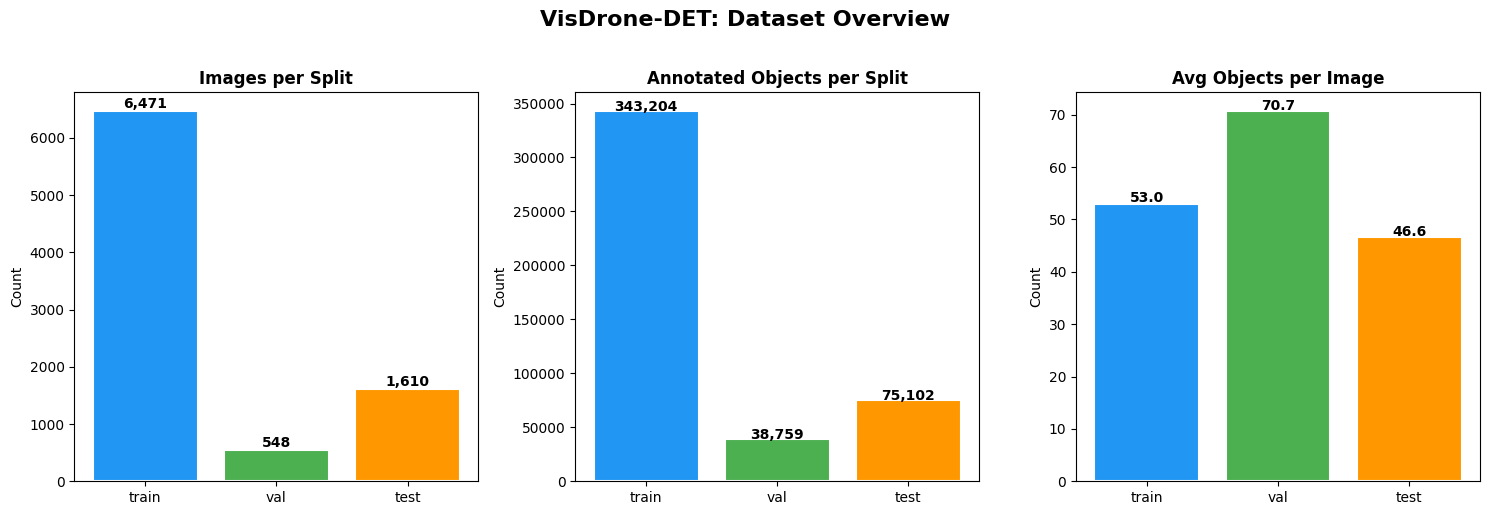


Dataset Summary:
  Total images:  8,629
  Total objects: 457,065
  Overall avg objects/image: 53.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('VisDrone-DET: Dataset Overview', fontsize=16, fontweight='bold', y=1.02)

split_imgs = {'train': 6471, 'val': 548, 'test': 1610}
colors = ['#2196F3', '#4CAF50', '#FF9800']

bars = axes[0].bar(split_imgs.keys(), split_imgs.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Images per Split', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, split_imgs.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')

obj_counts = {k: len(v) for k, v in dfs.items()}
bars2 = axes[1].bar(obj_counts.keys(), obj_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Annotated Objects per Split', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(bars2, obj_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold')

avg_objs = {k: len(v)/split_imgs[k] for k, v in dfs.items()}
bars3 = axes[2].bar(avg_objs.keys(), avg_objs.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Avg Objects per Image', fontweight='bold')
axes[2].set_ylabel('Count')
for bar, val in zip(bars3, avg_objs.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset Summary:")
print(f"  Total images:  {sum(split_imgs.values()):,}")
print(f"  Total objects: {len(df_all):,}")
print(f"  Overall avg objects/image: {len(df_all)/sum(split_imgs.values()):.1f}")

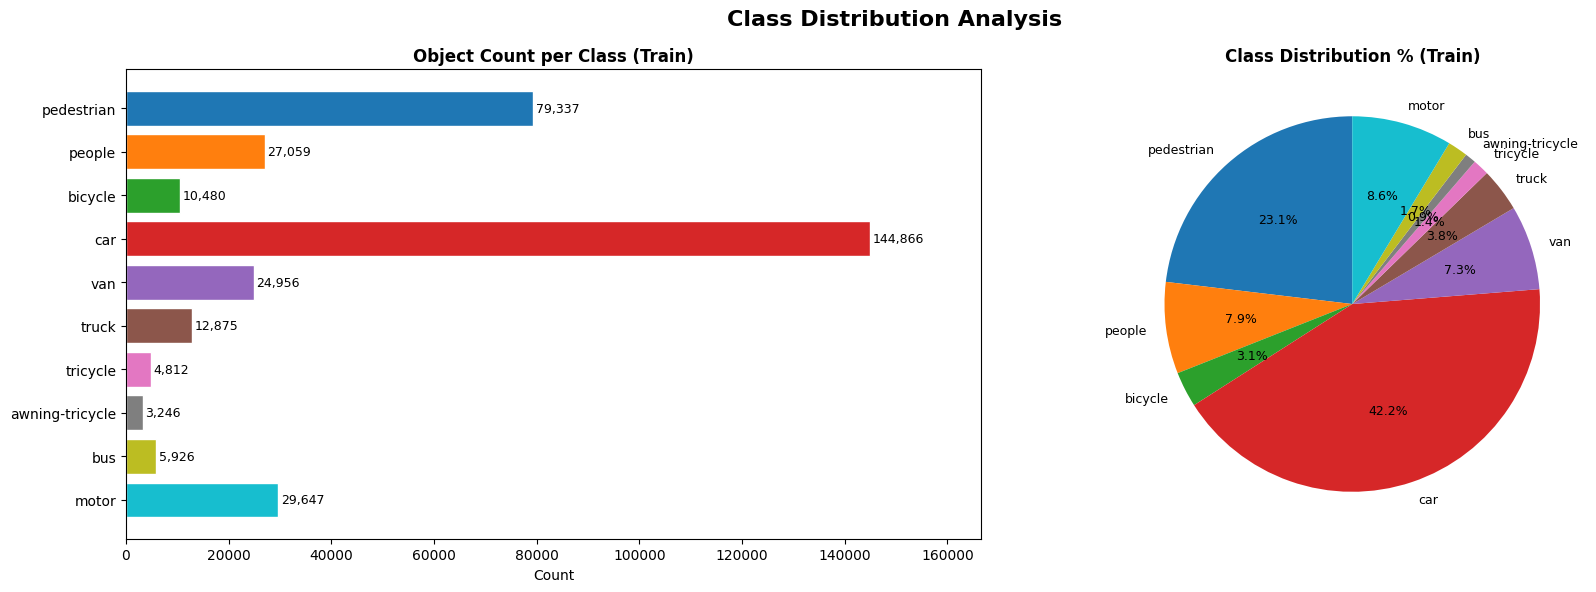


Class Distribution (Train):
Class                   Count        % Imbalance ratio
-------------------------------------------------------
pedestrian             79,337    23.1%            1.8x
people                 27,059     7.9%            5.4x
bicycle                10,480     3.1%           13.8x
car                   144,866    42.2%            1.0x
van                    24,956     7.3%            5.8x
truck                  12,875     3.8%           11.3x
tricycle                4,812     1.4%           30.1x
awning-tricycle         3,246     0.9%           44.6x
bus                     5,926     1.7%           24.4x
motor                  29,647     8.6%            4.9x


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Class Distribution Analysis', fontsize=16, fontweight='bold')

class_counts = df_train['class_name'].value_counts().reindex(CLASS_NAMES)
colors_cls = [CLASS_COLORS[i] for i in range(10)]

bars = axes[0].barh(CLASS_NAMES[::-1], class_counts[::-1],
                     color=colors_cls[::-1], edgecolor='white')
axes[0].set_title('Object Count per Class (Train)', fontweight='bold')
axes[0].set_xlabel('Count')
for bar, val in zip(bars, class_counts[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlim(0, class_counts.max() * 1.15)

pcts = class_counts / class_counts.sum() * 100
axes[1].pie(pcts, labels=CLASS_NAMES, colors=colors_cls,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Class Distribution % (Train)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass Distribution (Train):")
print(f"{'Class':<20} {'Count':>8} {'%':>8} {'Imbalance ratio':>15}")
print("-"*55)
max_count = class_counts.max()
for cls, cnt in class_counts.items():
    ratio = max_count / cnt if cnt > 0 else float('inf')
    print(f"{cls:<20} {cnt:>8,} {cnt/class_counts.sum()*100:>7.1f}% {ratio:>14.1f}x")

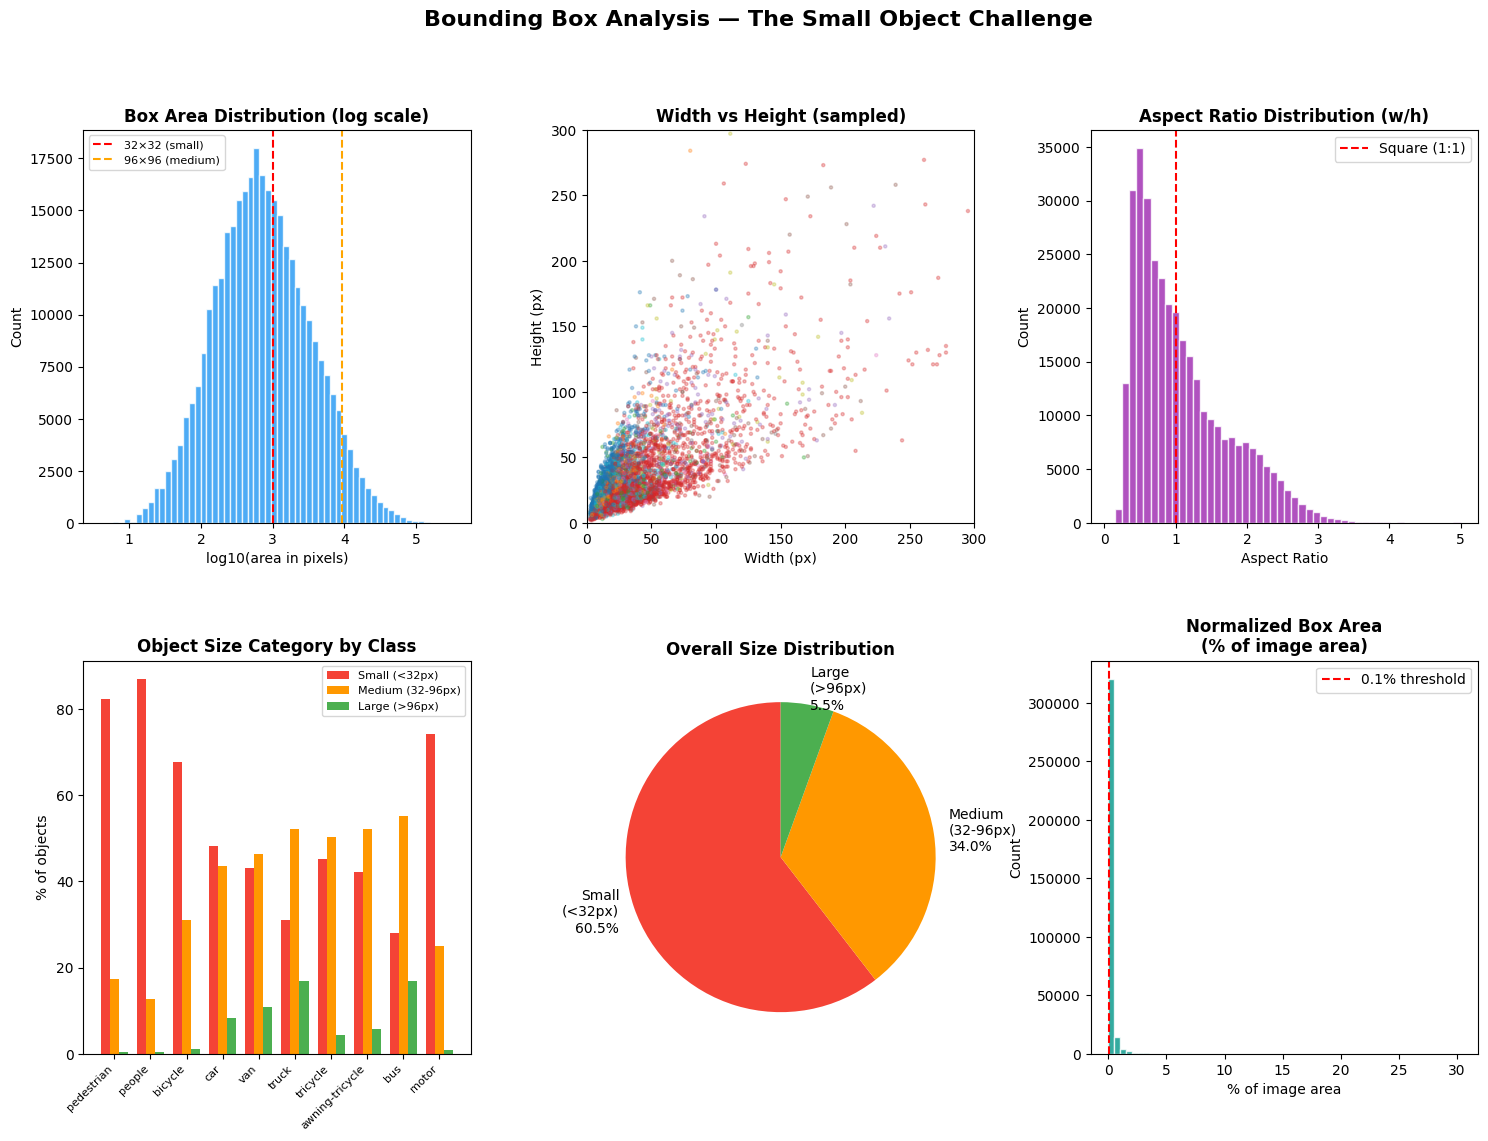


Key Finding: 69.0% of objects occupy <0.1% of image area


In [12]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Bounding Box Analysis — The Small Object Challenge', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(np.log10(df_train['area'] + 1), bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
ax1.set_title('Box Area Distribution (log scale)', fontweight='bold')
ax1.set_xlabel('log10(area in pixels)')
ax1.set_ylabel('Count')
ax1.axvline(np.log10(32*32), color='red', linestyle='--', label='32×32 (small)')
ax1.axvline(np.log10(96*96), color='orange', linestyle='--', label='96×96 (medium)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
sample = df_train.sample(min(5000, len(df_train)), random_state=42)
scatter_colors = [CLASS_COLORS[i] for i in sample['class_id']]
ax2.scatter(sample['w'], sample['h'], c=scatter_colors, alpha=0.3, s=5)
ax2.set_title('Width vs Height (sampled)', fontweight='bold')
ax2.set_xlabel('Width (px)'); ax2.set_ylabel('Height (px)')
ax2.set_xlim(0, 300); ax2.set_ylim(0, 300)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df_train['aspect'].clip(0, 5), bins=50, color='#9C27B0', edgecolor='white', alpha=0.8)
ax3.set_title('Aspect Ratio Distribution (w/h)', fontweight='bold')
ax3.set_xlabel('Aspect Ratio'); ax3.set_ylabel('Count')
ax3.axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
ax3.legend()

ax4 = fig.add_subplot(gs[1, 0])
small_threshold = 32 * 32
medium_threshold = 96 * 96
size_by_class = []
for cls in CLASS_NAMES:
    cls_df = df_train[df_train['class_name'] == cls]
    total = len(cls_df)
    if total == 0:
        continue
    small  = (cls_df['area'] < small_threshold).sum() / total * 100
    medium = ((cls_df['area'] >= small_threshold) & (cls_df['area'] < medium_threshold)).sum() / total * 100
    large  = (cls_df['area'] >= medium_threshold).sum() / total * 100
    size_by_class.append({'class': cls, 'small': small, 'medium': medium, 'large': large})

size_df = pd.DataFrame(size_by_class)
x = np.arange(len(size_df))
w = 0.25
ax4.bar(x - w, size_df['small'],  w, label='Small (<32px)',    color='#F44336')
ax4.bar(x,     size_df['medium'], w, label='Medium (32-96px)', color='#FF9800')
ax4.bar(x + w, size_df['large'],  w, label='Large (>96px)',    color='#4CAF50')
ax4.set_xticks(x)
ax4.set_xticklabels(size_df['class'], rotation=45, ha='right', fontsize=8)
ax4.set_title('Object Size Category by Class', fontweight='bold')
ax4.set_ylabel('% of objects')
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 1])
total = len(df_train)
s = (df_train['area'] < small_threshold).sum()
m = ((df_train['area'] >= small_threshold) & (df_train['area'] < medium_threshold)).sum()
l = (df_train['area'] >= medium_threshold).sum()
ax5.pie([s, m, l],
        labels=[f'Small\n(<32px)\n{s/total*100:.1f}%',
                f'Medium\n(32-96px)\n{m/total*100:.1f}%',
                f'Large\n(>96px)\n{l/total*100:.1f}%'],
        colors=['#F44336','#FF9800','#4CAF50'],
        startangle=90, textprops={'fontsize': 10})
ax5.set_title('Overall Size Distribution', fontweight='bold')

ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_train['area_norm'] * 100, bins=60, color='#009688', edgecolor='white', alpha=0.8)
ax6.set_title('Normalized Box Area\n(% of image area)', fontweight='bold')
ax6.set_xlabel('% of image area'); ax6.set_ylabel('Count')
ax6.axvline(0.1, color='red', linestyle='--', label='0.1% threshold')
ax6.legend()

plt.savefig('eda_bbox.png', dpi=150, bbox_inches='tight')
plt.show()
tiny = (df_train['area_norm'] < 0.001).sum()
print(f"\nKey Finding: {tiny/len(df_train)*100:.1f}% of objects occupy <0.1% of image area")

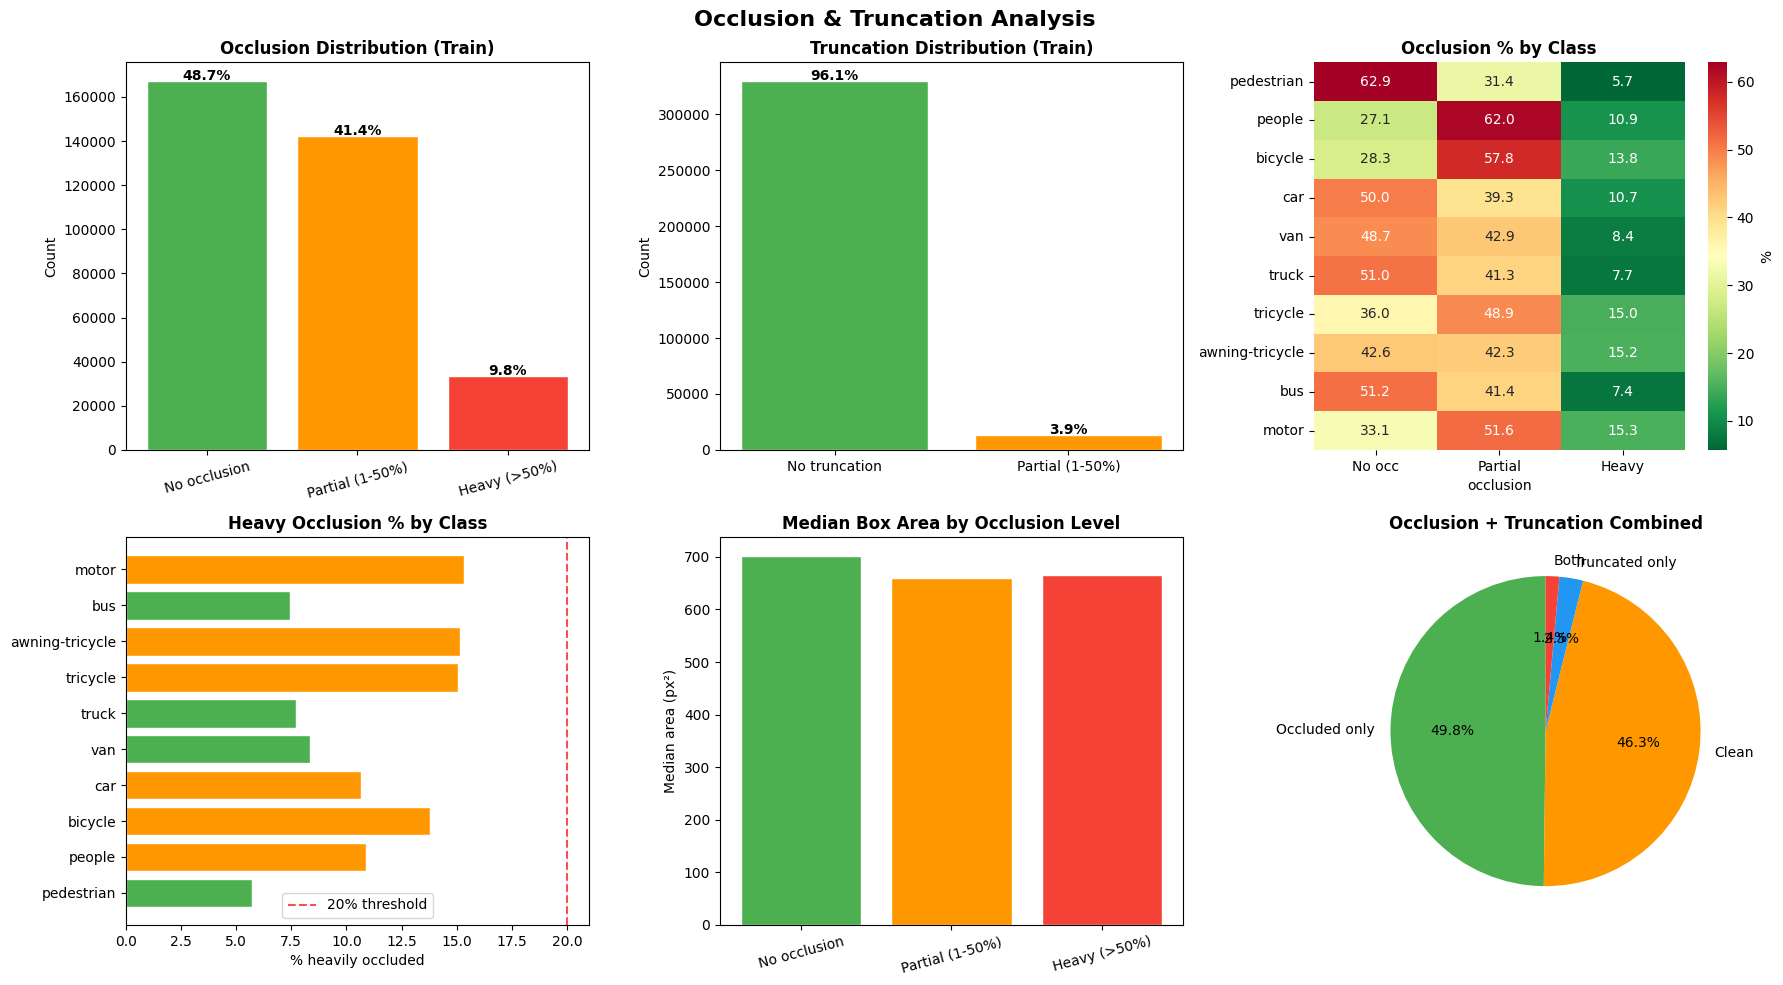

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Occlusion & Truncation Analysis', fontsize=16, fontweight='bold')

occ_labels  = {0: 'No occlusion', 1: 'Partial (1-50%)', 2: 'Heavy (>50%)'}
trunc_labels = {0: 'No truncation', 1: 'Partial (1-50%)'}

occ_counts = df_train['occlusion'].value_counts().sort_index()
axes[0,0].bar([occ_labels.get(i, str(i)) for i in occ_counts.index],
              occ_counts.values,
              color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[0,0].set_title('Occlusion Distribution (Train)', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=15)
for i, (idx, val) in enumerate(occ_counts.items()):
    axes[0,0].text(i, val + 500, f'{val/len(df_train)*100:.1f}%', ha='center', fontweight='bold')

trunc_counts = df_train['truncation'].value_counts().sort_index()
axes[0,1].bar([trunc_labels.get(i, str(i)) for i in trunc_counts.index],
              trunc_counts.values,
              color=['#4CAF50','#FF9800'], edgecolor='white')
axes[0,1].set_title('Truncation Distribution (Train)', fontweight='bold')
axes[0,1].set_ylabel('Count')
for i, (idx, val) in enumerate(trunc_counts.items()):
    axes[0,1].text(i, val + 500, f'{val/len(df_train)*100:.1f}%', ha='center', fontweight='bold')

occ_by_class = pd.crosstab(df_train['class_name'], df_train['occlusion'], normalize='index') * 100
occ_by_class = occ_by_class.reindex(CLASS_NAMES)
sns.heatmap(occ_by_class, ax=axes[0,2], annot=True, fmt='.1f',
            cmap='RdYlGn_r', cbar_kws={'label': '%'},
            xticklabels=['No occ', 'Partial', 'Heavy'])
axes[0,2].set_title('Occlusion % by Class', fontweight='bold')
axes[0,2].set_ylabel('')

heavy_occ = df_train.groupby('class_name').apply(
    lambda x: (x['occlusion'] == 2).sum() / len(x) * 100).reindex(CLASS_NAMES)
colors_occ = ['#F44336' if v > 20 else '#FF9800' if v > 10 else '#4CAF50' for v in heavy_occ]
axes[1,0].barh(CLASS_NAMES, heavy_occ, color=colors_occ, edgecolor='white')
axes[1,0].set_title('Heavy Occlusion % by Class', fontweight='bold')
axes[1,0].set_xlabel('% heavily occluded')
axes[1,0].axvline(20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
axes[1,0].legend()

occ_size = df_train.groupby('occlusion')['area'].median()
axes[1,1].bar([occ_labels.get(i, str(i)) for i in occ_size.index],
              occ_size.values, color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[1,1].set_title('Median Box Area by Occlusion Level', fontweight='bold')
axes[1,1].set_ylabel('Median area (px²)')
axes[1,1].tick_params(axis='x', rotation=15)

combined = df_train.copy()
combined['status'] = 'Clean'
combined.loc[(combined['occlusion'] > 0) & (combined['truncation'] == 0), 'status'] = 'Occluded only'
combined.loc[(combined['occlusion'] == 0) & (combined['truncation'] > 0), 'status'] = 'Truncated only'
combined.loc[(combined['occlusion'] > 0) & (combined['truncation'] > 0), 'status'] = 'Both'
status_counts = combined['status'].value_counts()
axes[1,2].pie(status_counts, labels=status_counts.index,
              autopct='%1.1f%%', colors=['#4CAF50','#FF9800','#2196F3','#F44336'],
              startangle=90)
axes[1,2].set_title('Occlusion + Truncation Combined', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_occlusion.png', dpi=150, bbox_inches='tight')
plt.show()

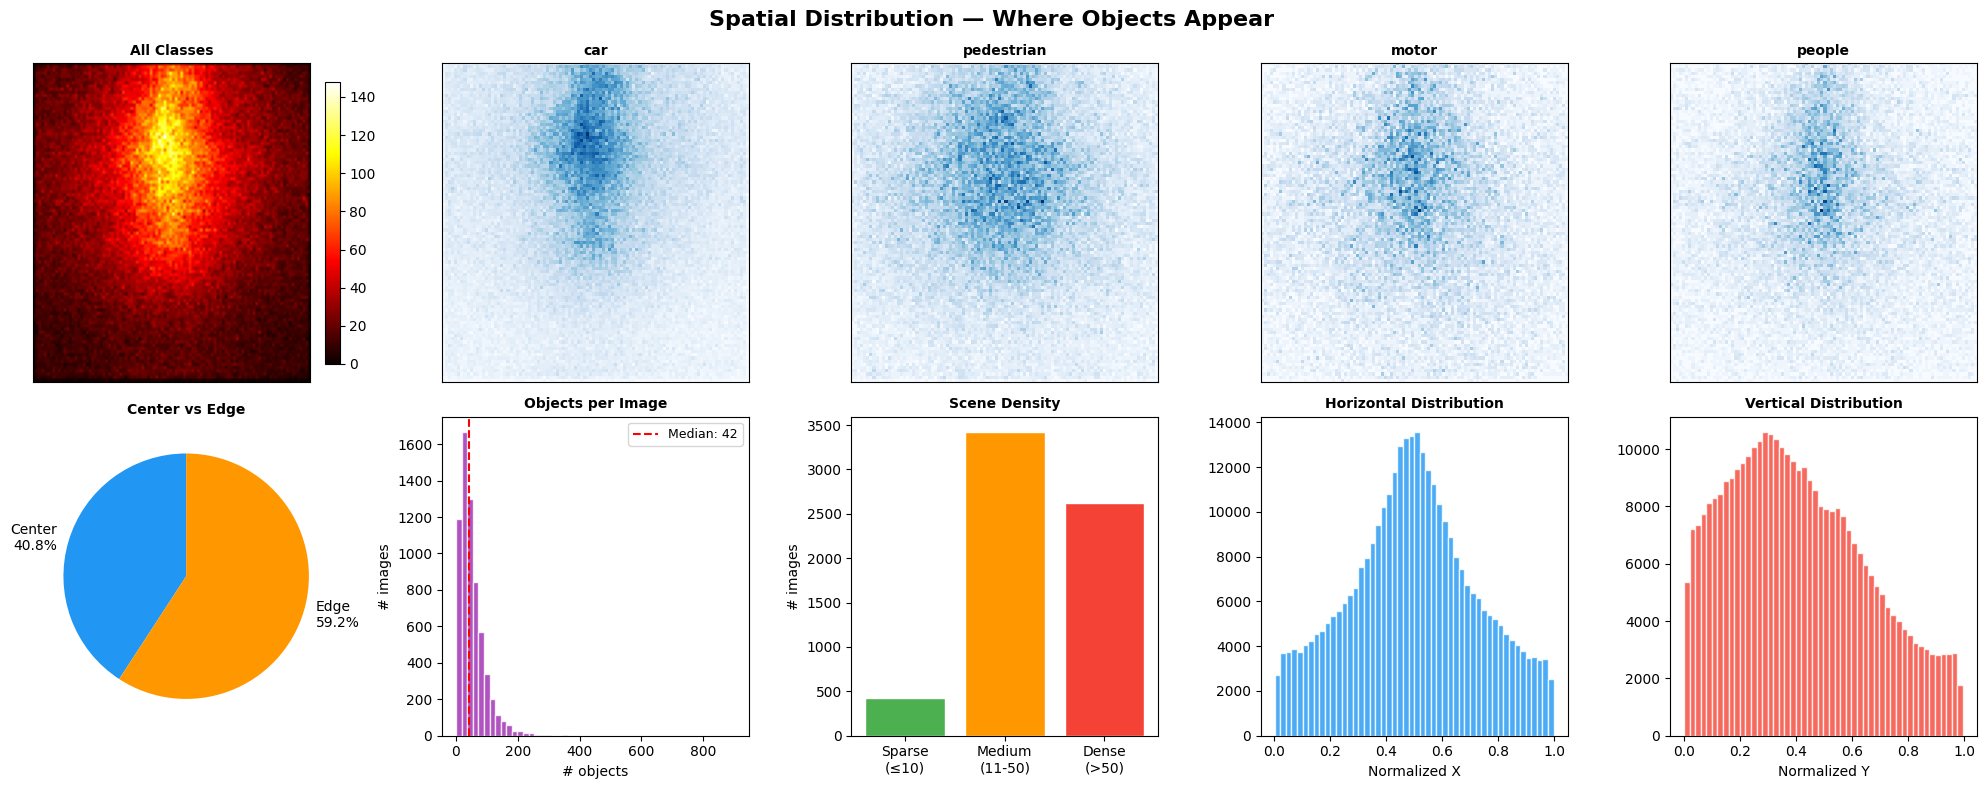

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Spatial Distribution — Where Objects Appear', fontsize=16, fontweight='bold')

H_map, W_map = 100, 100
overall_heatmap = np.zeros((H_map, W_map))
for _, row in df_train.iterrows():
    cx_idx = min(int(row['cx_norm'] * W_map), W_map-1)
    cy_idx = min(int(row['cy_norm'] * H_map), H_map-1)
    overall_heatmap[cy_idx, cx_idx] += 1

im = axes[0,0].imshow(overall_heatmap, cmap='hot', aspect='auto')
axes[0,0].set_title('All Classes', fontweight='bold', fontsize=10)
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])
plt.colorbar(im, ax=axes[0,0], fraction=0.046)

top_classes = df_train['class_name'].value_counts().head(4).index.tolist()
for i, cls in enumerate(top_classes):
    cls_df = df_train[df_train['class_name'] == cls]
    hm = np.zeros((H_map, W_map))
    for _, row in cls_df.iterrows():
        cx_idx = min(int(row['cx_norm'] * W_map), W_map-1)
        cy_idx = min(int(row['cy_norm'] * H_map), H_map-1)
        hm[cy_idx, cx_idx] += 1
    axes[0, i+1].imshow(hm, cmap='Blues', aspect='auto')
    axes[0, i+1].set_title(cls, fontweight='bold', fontsize=10)
    axes[0, i+1].set_xticks([]); axes[0, i+1].set_yticks([])

center_mask = (
    (df_train['cx_norm'] > 0.25) & (df_train['cx_norm'] < 0.75) &
    (df_train['cy_norm'] > 0.25) & (df_train['cy_norm'] < 0.75)
)
center_pct = center_mask.sum() / len(df_train) * 100
axes[1,0].pie([center_pct, 100-center_pct],
              labels=[f'Center\n{center_pct:.1f}%', f'Edge\n{100-center_pct:.1f}%'],
              colors=['#2196F3','#FF9800'], startangle=90)
axes[1,0].set_title('Center vs Edge', fontweight='bold', fontsize=10)

objs_per_img = df_train.groupby('image').size()
axes[1,1].hist(objs_per_img, bins=50, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Objects per Image', fontweight='bold', fontsize=10)
axes[1,1].set_xlabel('# objects'); axes[1,1].set_ylabel('# images')
axes[1,1].axvline(objs_per_img.median(), color='red', linestyle='--',
                   label=f'Median: {objs_per_img.median():.0f}')
axes[1,1].legend(fontsize=9)

dense  = (objs_per_img > 50).sum()
sparse = (objs_per_img <= 10).sum()
mid    = ((objs_per_img > 10) & (objs_per_img <= 50)).sum()
axes[1,2].bar(['Sparse\n(≤10)', 'Medium\n(11-50)', 'Dense\n(>50)'],
              [sparse, mid, dense],
              color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[1,2].set_title('Scene Density', fontweight='bold', fontsize=10)
axes[1,2].set_ylabel('# images')

axes[1,3].hist(df_train['cx_norm'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1,3].set_title('Horizontal Distribution', fontweight='bold', fontsize=10)
axes[1,3].set_xlabel('Normalized X')

axes[1,4].hist(df_train['cy_norm'], bins=50, color='#F44336', edgecolor='white', alpha=0.8)
axes[1,4].set_title('Vertical Distribution', fontweight='bold', fontsize=10)
axes[1,4].set_xlabel('Normalized Y')

plt.tight_layout()
plt.savefig('eda_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

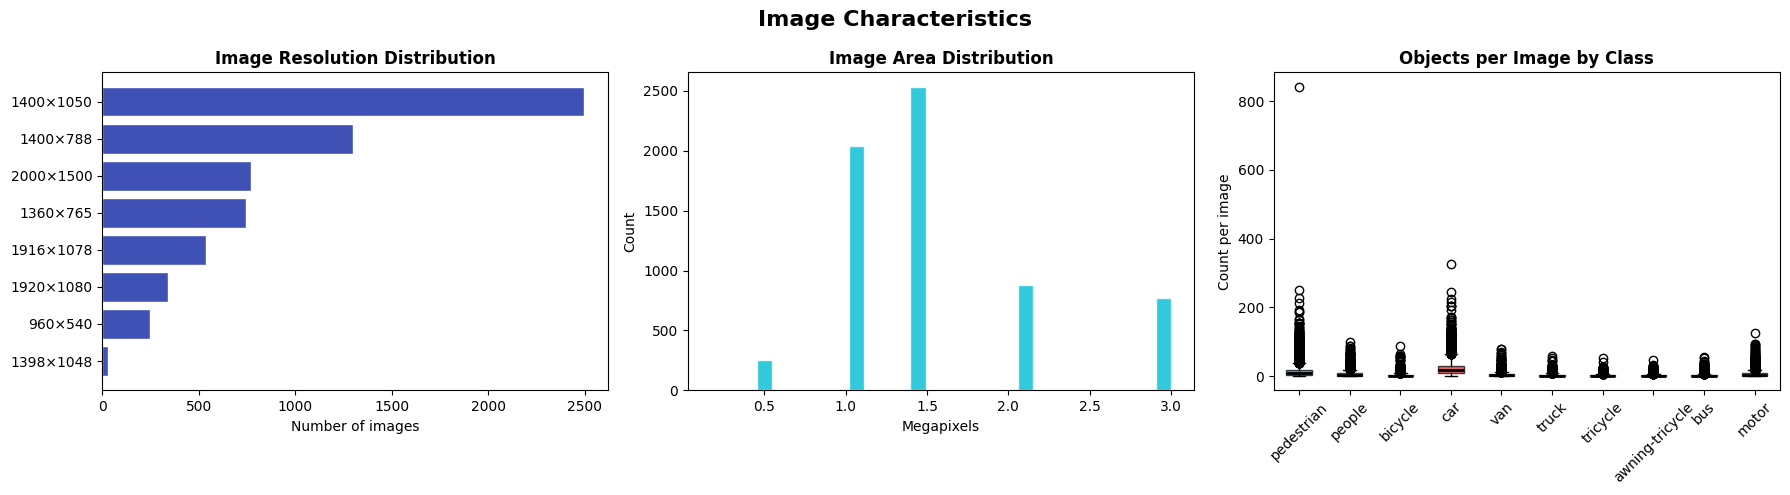

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Characteristics', fontsize=16, fontweight='bold')

resolutions = df_train.drop_duplicates('image')[['img_w','img_h']].value_counts().reset_index()
resolutions.columns = ['w', 'h', 'count']
resolutions['label'] = resolutions['w'].astype(str) + '×' + resolutions['h'].astype(str)
top_res = resolutions.head(8)
axes[0].barh(top_res['label'][::-1], top_res['count'][::-1], color='#3F51B5', edgecolor='white')
axes[0].set_title('Image Resolution Distribution', fontweight='bold')
axes[0].set_xlabel('Number of images')

img_areas = df_train.drop_duplicates('image')['img_pixels']
axes[1].hist(img_areas / 1e6, bins=30, color='#00BCD4', edgecolor='white', alpha=0.8)
axes[1].set_title('Image Area Distribution', fontweight='bold')
axes[1].set_xlabel('Megapixels'); axes[1].set_ylabel('Count')

objs_per_img_class = df_train.groupby(['image','class_name']).size().reset_index(name='count')
bp_data = [objs_per_img_class[objs_per_img_class['class_name']==c]['count'].values
           for c in CLASS_NAMES]
bp = axes[2].boxplot(bp_data, labels=CLASS_NAMES, patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Objects per Image by Class', fontweight='bold')
axes[2].set_ylabel('Count per image')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_images.png', dpi=150, bbox_inches='tight')
plt.show()

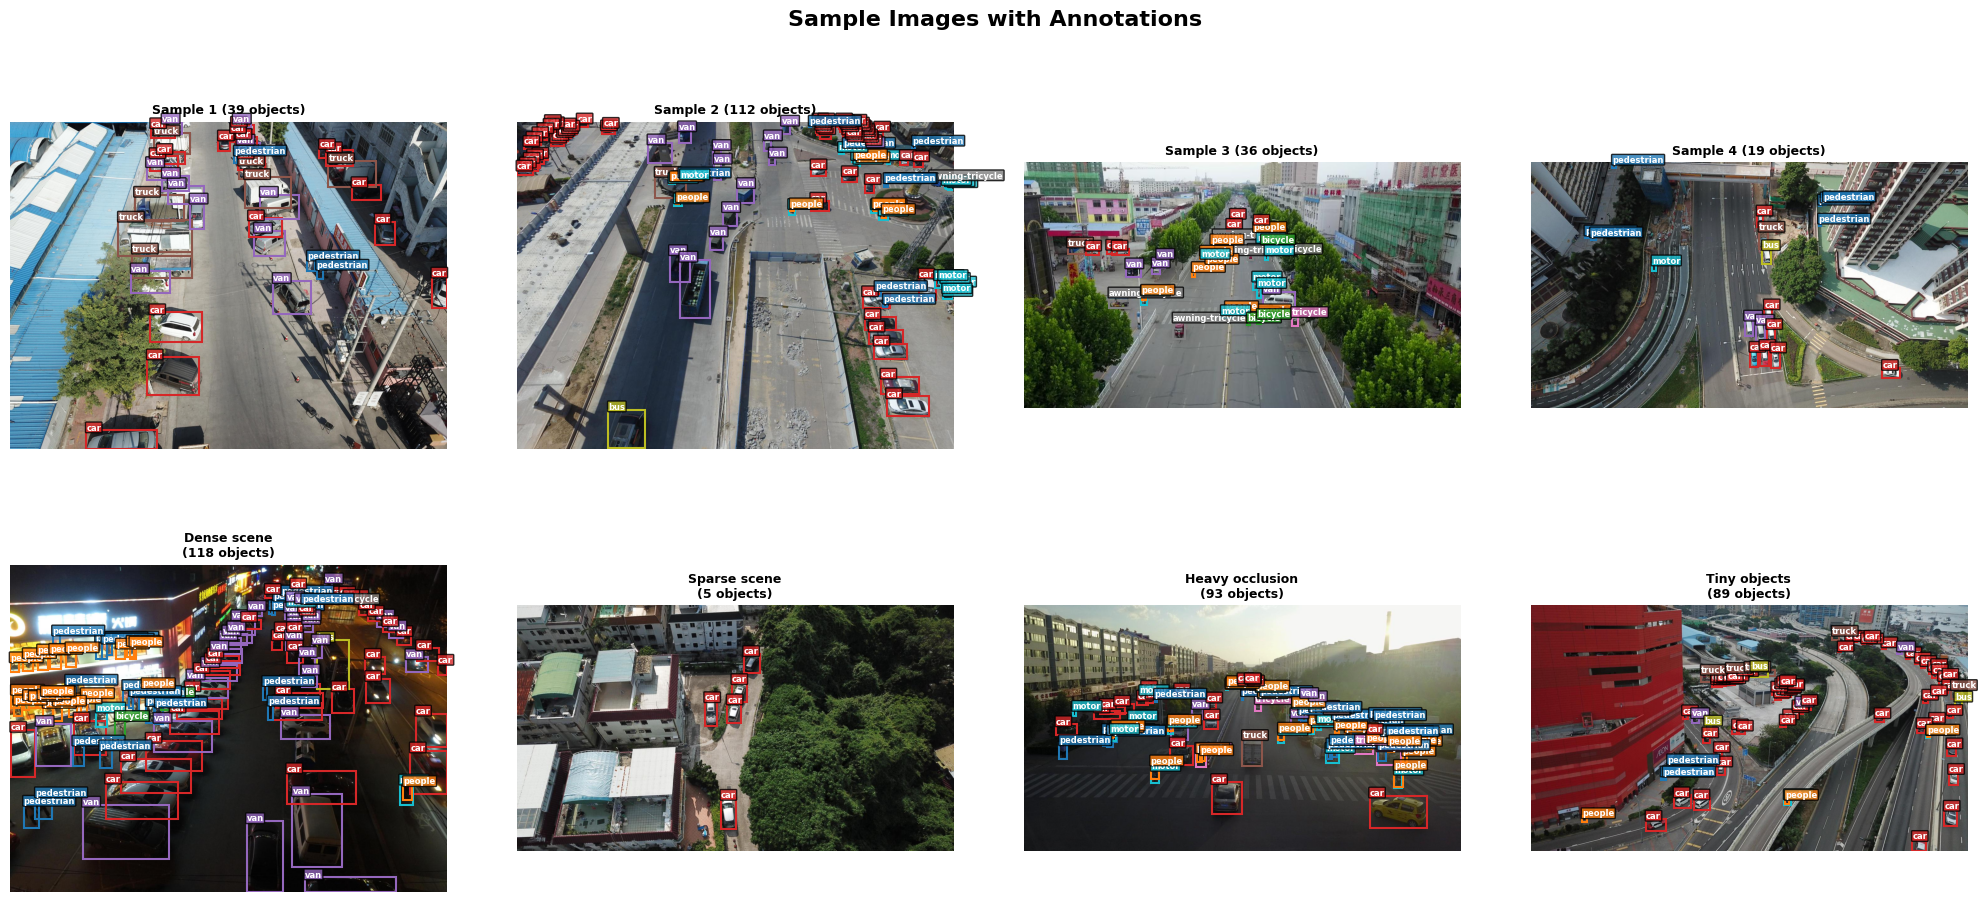

In [16]:
import random

def draw_sample(ax, img_path, ann_path, title=""):
    img = np.array(Image.open(img_path))
    ax.imshow(img)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    if not ann_path.exists():
        return
    with open(ann_path) as f:
        lines = f.read().strip().splitlines()
    for line in lines:
        parts = line.split(',')
        if len(parts) < 6:
            continue
        bx, by, bw, bh = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
        score, cat = int(parts[4]), int(parts[5])
        if score == 0 or cat == 0 or cat == 11:
            continue
        cls_idx = cat - 1
        color = CLASS_COLORS[cls_idx]
        rect = patches.Rectangle((bx, by), bw, bh,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(bx, by-2, CLASS_NAMES[cls_idx], fontsize=6, color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor=color, alpha=0.8))

train_path  = SPLITS['train']
train_imgs  = sorted((train_path/'images').glob('*.jpg'))
train_anns  = train_path / 'annotations'

objs_per_img = df_train.groupby('image').size()
sparse_imgs      = objs_per_img[objs_per_img <= 10].index.tolist()
dense_imgs       = objs_per_img[objs_per_img > 100].index.tolist()
heavy_occ_imgs   = df_train[df_train['occlusion']==2]['image'].unique().tolist()
small_obj_imgs   = df_train[df_train['area'] < 500]['image'].unique().tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sample Images with Annotations', fontsize=16, fontweight='bold')

samples = random.sample(train_imgs, 4)
for i, img_path in enumerate(samples):
    ann_path = train_anns / (img_path.stem + '.txt')
    n_objs = len(df_train[df_train['image'] == img_path.stem])
    draw_sample(axes[0,i], img_path, ann_path, f"Sample {i+1} ({n_objs} objects)")

challenging = {
    'Dense scene':      random.choice(dense_imgs)     if dense_imgs     else None,
    'Sparse scene':     random.choice(sparse_imgs)    if sparse_imgs    else None,
    'Heavy occlusion':  random.choice(heavy_occ_imgs) if heavy_occ_imgs else None,
    'Tiny objects':     random.choice(small_obj_imgs) if small_obj_imgs else None,
}
for i, (case, img_stem) in enumerate(challenging.items()):
    if img_stem:
        img_path = train_path/'images'/(img_stem+'.jpg')
        ann_path = train_anns/(img_stem+'.txt')
        n_objs = len(df_train[df_train['image']==img_stem])
        draw_sample(axes[1,i], img_path, ann_path, f"{case}\n({n_objs} objects)")

plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("="*60)
print("VISDRONE-DET EDA SUMMARY")
print("="*60)

total_objs    = len(df_train)
small_pct     = (df_train['area'] < 32*32).sum() / total_objs * 100
heavy_occ_pct = (df_train['occlusion'] == 2).sum() / total_objs * 100
objs_per_img  = df_train.groupby('image').size()

print(f"\n📊 DATASET")
print(f"   Train images:        {6471:,}")
print(f"   Train objects:       {total_objs:,}")
print(f"   Avg objects/image:   {total_objs/6471:.1f}")

print(f"\n🔬 SMALL OBJECT CHALLENGE")
print(f"   Objects < 32×32px:   {small_pct:.1f}%")
print(f"   Objects < 0.1% img:  {(df_train['area_norm']<0.001).sum()/total_objs*100:.1f}%")
print(f"   Median box area:     {df_train['area'].median():.0f} px²")

print(f"\n👁 OCCLUSION")
print(f"   Heavy occlusion:     {heavy_occ_pct:.1f}%")
print(f"   Any occlusion:       {(df_train['occlusion']>0).sum()/total_objs*100:.1f}%")

print(f"\n📦 CLASS IMBALANCE")
cc = df_train['class_name'].value_counts()
print(f"   Most common:  {cc.index[0]} ({cc.iloc[0]:,})")
print(f"   Least common: {cc.index[-1]} ({cc.iloc[-1]:,})")
print(f"   Imbalance ratio: {cc.iloc[0]/cc.iloc[-1]:.1f}x")

print(f"\n🏙 SCENE COMPLEXITY")
print(f"   Max objects/image:   {objs_per_img.max()}")
print(f"   Median objects/img:  {objs_per_img.median():.0f}")
print(f"   Dense scenes (>50):  {(objs_per_img>50).sum()} images")

print(f"\n💡 KEY INSIGHT FOR OUR PROJECT")
print(f"   {small_pct:.0f}% of objects are tiny (<32px)")
print(f"   Motivates: 1024px training + CBAM attention for small objects")

VISDRONE-DET EDA SUMMARY

📊 DATASET
   Train images:        6,471
   Train objects:       343,204
   Avg objects/image:   53.0

🔬 SMALL OBJECT CHALLENGE
   Objects < 32×32px:   60.5%
   Objects < 0.1% img:  69.0%
   Median box area:     680 px²

👁 OCCLUSION
   Heavy occlusion:     9.8%
   Any occlusion:       51.3%

📦 CLASS IMBALANCE
   Most common:  car (144,866)
   Least common: awning-tricycle (3,246)
   Imbalance ratio: 44.6x

🏙 SCENE COMPLEXITY
   Max objects/image:   902
   Median objects/img:  42
   Dense scenes (>50):  2624 images

💡 KEY INSIGHT FOR OUR PROJECT
   60% of objects are tiny (<32px)
   Motivates: 1024px training + CBAM attention for small objects
